### Downloading Data & visualizing it 

In [1]:
import kagglehub

path = kagglehub.dataset_download('andrewmvd/pollen-grain-image-classification')
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pollen-grain-image-classification' dataset.
Path to dataset files: /kaggle/input/pollen-grain-image-classification


Found 790 images.
Displaying image: /kaggle/input/pollen-grain-image-classification/combretum_11.jpg
Displaying image: /kaggle/input/pollen-grain-image-classification/faramea_15.jpg
Displaying image: /kaggle/input/pollen-grain-image-classification/myrcia_34.jpg
Displaying image: /kaggle/input/pollen-grain-image-classification/croton_22.jpg
Displaying image: /kaggle/input/pollen-grain-image-classification/arecaceae_16.jpg


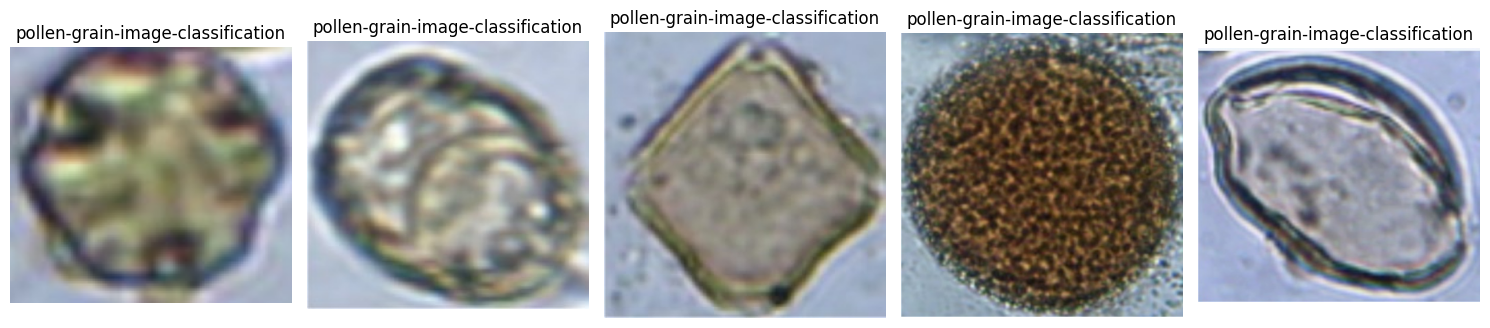

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Walk through the directory to find image files
image_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, file))

print(f"Found {len(image_files)} images.")

# Display the first 5 images
num_images_to_show = 5

if num_images_to_show > 0:
    plt.figure(figsize=(15, 5))
    for i in range(num_images_to_show):
        img_path = image_files[i]
        print(f"Displaying image: {img_path}")
        img = Image.open(img_path)
        
        # Plot each image
        plt.subplot(1, num_images_to_show, i + 1)
        plt.imshow(img)
        
        # Use the parent folder name as the title (usually the class label)
        label = os.path.basename(img_path.split(os.sep)[-2])
        plt.title(label)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("No images found in the downloaded dataset.")

### Organizing data inside workdir 

In [3]:
import os
import shutil

# 1. Define where we want to put the organized folders
organized_path = "./data/organized_pollen_data"
os.makedirs(organized_path, exist_ok=True)

print("Starting to organize files...")

# We will reuse the 'image_files' list you made in your second block
for img_path in image_files:
    filename = os.path.basename(img_path)
    
    # 2. Extract the class name from the filename
    # Assuming filenames look like "ClassName_001.jpg" or "Class_Name_001.jpg"
    # We split by '_' and drop the last part (which is usually the number)
    parts = filename.split('_')
    
 
        # Join everything except the last part back together
    class_name = "_".join(parts[:-1]) 
  

    # 3. Create a folder for this specific class if it doesn't exist yet
    class_folder = os.path.join(organized_path, class_name)
    os.makedirs(class_folder, exist_ok=True)
    
    # 4. Copy the image into its new class folder
    dest_path = os.path.join(class_folder, filename)
    if not os.path.exists(dest_path):
        shutil.copy(img_path, dest_path)

print(f"Success! Data is now organized into subfolders inside: {organized_path}")

Starting to organize files...
Success! Data is now organized into subfolders inside: ./data/organized_pollen_data


In [4]:
import tensorflow as tf

# 1. Define standard variables
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224) 

print("Loading data...")

# 2. Create the Training Dataset (80% of the images)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    organized_path,                    # The directory you got from Kagglehub
    validation_split=0.2,    # Keep 20% of data aside for testing
    subset="training",       # This defines that we are making the training set
    seed=123,                # A random seed ensures we get the same split every time
    image_size=IMAGE_SIZE,   # Resizes all images to 224x224 pixels
    batch_size=BATCH_SIZE    # Groups images into batches of 32
)

# 3. Create the Validation Dataset (20% of the images)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    organized_path,
    validation_split=0.2,
    subset="validation",     # This defines that we are making the testing set
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# 4. Extract and print the class names
class_names = train_dataset.class_names
print(f"Found {len(class_names)} different types of pollen:")
print(class_names)

Loading data...
Found 790 files belonging to 22 classes.
Using 632 files for training.
Found 790 files belonging to 22 classes.
Using 158 files for validation.
Found 22 different types of pollen:
['Unknown', 'anadenanthera', 'arecaceae', 'arrabidaea', 'cecropia', 'chromolaena', 'combretum', 'croton', 'dipteryx', 'eucalipto', 'faramea', 'hyptis', 'mabea', 'matayba', 'mimosa', 'myrcia', 'protium', 'qualea', 'schinus', 'serjania', 'syagrus', 'tridax']
